<a href="https://colab.research.google.com/github/AadityaSukhoi/CNN-Models/blob/main/Lab_Practical_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Neural Networks and Deep Learning Lab**
A robotics team needs an image classifier for basic object recognition (cars, animals, airplanes). Train a CNN on CIFAR-10 and test performance with and without data augmentation.

In [1]:
# Import all the dependencies
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [15]:
def create_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [16]:
# CNN Model (Without Data Augmentation)

model_no_aug = create_model()

history_no_aug = model_no_aug.fit(
    x_train, y_train,
    epochs=15,
    validation_data=(x_test, y_test),
    batch_size=64
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.1864 - loss: 2.0737 - val_accuracy: 0.3739 - val_loss: 1.6712
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4118 - loss: 1.5593 - val_accuracy: 0.5697 - val_loss: 1.1910
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5740 - loss: 1.1846 - val_accuracy: 0.6350 - val_loss: 1.0377
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6524 - loss: 0.9930 - val_accuracy: 0.6519 - val_loss: 1.0053
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6896 - loss: 0.8755 - val_accuracy: 0.6945 - val_loss: 0.8840
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7370 - loss: 0.7605 - val_accuracy: 0.7185 - val_loss: 0.8294
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7669 - loss: 0.6811 - val_accuracy: 0.7181 - val_loss: 0.8442
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7930 - loss: 0.6052 - 

In [17]:
# CNN Model (with Data Augmentation)

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.15,
    fill_mode='nearest'
)

datagen.fit(x_train)

model_aug = create_model()

history_aug = model_aug.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=15,
    validation_data=(x_test, y_test),
    steps_per_epoch=len(x_train)//64
)

Epoch 1/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - accuracy: 0.1002 - loss: 2.3014 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 2/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0938 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 3/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.0994 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0938 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.0950 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1406 - loss: 2.3013 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.0980 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1875 - loss: 2.3003 - val_accu

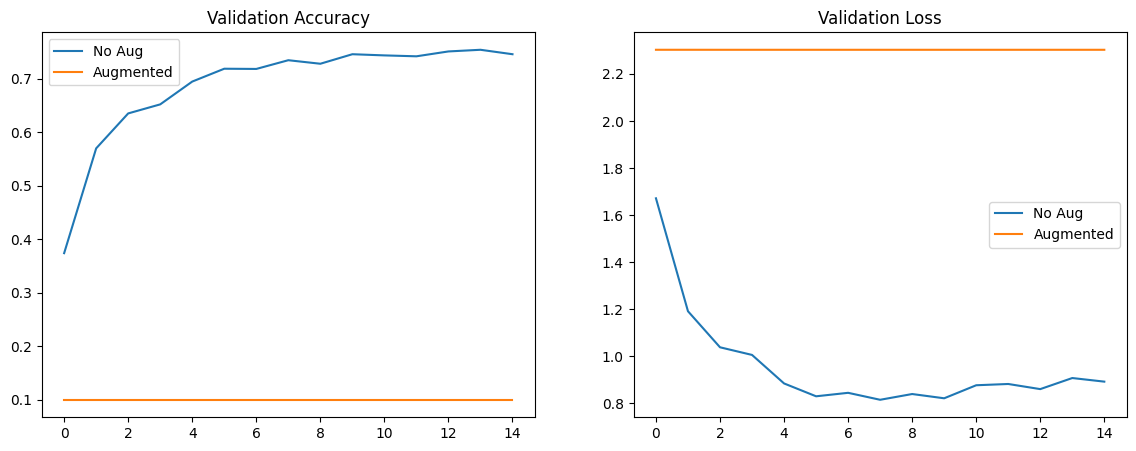

In [18]:
# Compare Performance

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_no_aug.history['val_accuracy'], label="No Aug")
plt.plot(history_aug.history['val_accuracy'], label="Augmented")
plt.title("Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_no_aug.history['val_loss'], label="No Aug")
plt.plot(history_aug.history['val_loss'], label="Augmented")
plt.title("Validation Loss")
plt.legend()

plt.show()

In [19]:
# Final Test Accuracy

test_no_aug = model_no_aug.evaluate(x_test, y_test, verbose=0)
test_aug = model_aug.evaluate(x_test, y_test, verbose=0)

print("Test Accuracy WITHOUT Augmentation:", test_no_aug[1])
print("Test Accuracy WITH Augmentation:", test_aug[1])

Test Accuracy WITHOUT Augmentation: 0.7455999851226807
Test Accuracy WITH Augmentation: 0.10000000149011612
